# 04 — Feature Engineering

In [ ]:
import json
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})


# 4.1 Load Outputs

In [ ]:
demand   = pd.read_parquet(PROCESSED_DIR / "hourly_demand.parquet")
stations = pd.read_parquet(PROCESSED_DIR / "stations_metadata_train.parquet")

stations = stations[
    (stations['latitude'] > 40.68) & 
    (stations['longitude'] > -74.05) &
    # As of ROADMAP Phase 4, notebook 03's Section 3.3 already filters
    # `stations_metadata_train.parquet` down to train-active stations before
    # saving it, so this is now a defensive no-op — kept as cheap insurance
    # in case that upstream filter is ever reverted.
    (stations['avg_trips_per_hour'] > 0) # Only take stations that are in train period
].dropna(subset=['total_trips', 'latitude', 'longitude'])

demand = demand[demand["station_id"].isin(stations["station_id"])].reset_index(drop=True)

# Load original adjacency matrices
adj_knn_full  = np.load(PROCESSED_DIR / "adj_knn.npy")
adj_flow_full = np.load(PROCESSED_DIR / "adj_flow_train.npy")

# Create station-to-index mapping from ORIGINAL full stations
stations_full = pd.read_parquet(PROCESSED_DIR / "stations_metadata_train.parquet")
station_to_idx_full = {sid: i for i, sid in enumerate(stations_full['station_id'])}

# Get valid indices
valid_indices = [station_to_idx_full[sid] for sid in stations['station_id']]

# Filter adjacency matrices
adj_knn  = adj_knn_full[np.ix_(valid_indices, valid_indices)]
adj_flow = adj_flow_full[np.ix_(valid_indices, valid_indices)]

# Create new filtered station-to-index mapping
station_to_idx = {sid: i for i, sid in enumerate(stations['station_id'])}

print("Hourly demand shape :", demand.shape)
print("Stations shape       :", stations.shape)
print("adj_knn  shape       :", adj_knn.shape)
print("adj_flow shape       :", adj_flow.shape)
print(f"Filtered to {len(stations)} stations")

del stations_full, station_to_idx_full, adj_knn_full, adj_flow_full  # Clean up memory

# 4.2 Target Variable Preparation

In [ ]:
time_col    = [c for c in demand.columns if c in ("hour", "timestamp", "started_hour")][0]
station_col = [c for c in demand.columns if "station" in c.lower()][0]
demand_col  = [c for c in demand.columns if c in ("departures", "demand", "trip_count")][0]

print(f"Using: time={time_col!r}, station={station_col!r}, demand={demand_col!r}")

demand = demand.rename(columns={
    time_col:    "timestamp",
    station_col: "station_id",
    demand_col:  "departures",
})
demand["timestamp"] = pd.to_datetime(demand["timestamp"])
demand = demand[["station_id", "timestamp", "departures"]]
display(demand.head())

Using: time='timestamp', station='station_id', demand='demand'


,station_id,timestamp,departures
0,190 Morgan,2024-02-23 12:00:00,1
1,4181.1,2024-01-01 00:00:00,1
2,4181.1,2024-01-01 08:00:00,1
3,4181.1,2024-01-01 14:00:00,2
4,4181.1,2024-01-01 15:00:00,1


In [ ]:
all_stations = sorted(demand["station_id"].unique())
n_stations   = len(all_stations)

# NYC observes US DST — 2024-03-10 02:00:00 local time never occurred
# (clocks jumped 02:00 → 03:00). A tz-naive hourly range silently includes
# it; reindexing would then fabricate a fake zero-demand row for every
# station at a timestamp that never happened. Drop it explicitly.
# (ROADMAP Phase 4)
DST_SPRING_FORWARD_2024 = pd.Timestamp("2024-03-10 02:00:00")

full_hours = pd.date_range(
    start=demand["timestamp"].min().floor("h"),
    end=demand["timestamp"].max().ceil("h") - pd.Timedelta(hours=1),
    freq="h",
)
full_hours = full_hours[full_hours != DST_SPRING_FORWARD_2024]

full_index = pd.MultiIndex.from_product(
    [all_stations, full_hours],
    names=["station_id", "timestamp"],
)

demand_full = (
    demand
    .set_index(["station_id", "timestamp"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

print(f"Stations  : {n_stations}")
print(f"Hours     : {len(full_hours)}  (excludes {DST_SPRING_FORWARD_2024}, a nonexistent NYC local hour)")
print(f"Total rows: {len(demand_full):,}")
print(f"Date range: {full_hours[0].date()} → {full_hours[-1].date()}")


In [ ]:
# Map Station ID to integer index
station_id_to_idx = {sid: i for i, sid in enumerate(all_stations)}
idx_to_station_id = {i: sid for sid, i in station_id_to_idx.items()}

demand_full["station_idx"] = demand_full["station_id"].map(station_id_to_idx)

print("Sample mapping (first 5):")
for sid, idx in list(station_id_to_idx.items())[:5]:
    print(f"  {str(sid):40s} → {idx}")

Sample mapping (first 5):
  190 Morgan                               → 0
  4181.1                                   → 1
  4181.10                                  → 2
  4184.08                                  → 3
  4193.14                                  → 4


# 4.3 Temporal Feature Engineering

In [ ]:
# Calendar Features
df = demand_full.copy().sort_values(["station_id", "timestamp"]).reset_index(drop=True)

df["hour_of_day"]  = df["timestamp"].dt.hour
df["day_of_week"]  = df["timestamp"].dt.dayofweek      # 0=Mon, 6=Sun
df["month"]        = df["timestamp"].dt.month
df["day_of_year"]  = df["timestamp"].dt.dayofyear
df["week_of_year"] = df["timestamp"].dt.isocalendar().week.astype(int)
df["is_weekend"]   = (df["day_of_week"] >= 5).astype(int)


In [ ]:
# Lag Features
df = df.sort_values(["station_id", "timestamp"])

for lag in [1, 24, 168]:
    df[f"lag_{lag}"] = df.groupby("station_id")["departures"].shift(lag)

print("Lag features added: lag_1, lag_24, lag_168")
print(f"Nulls from lag_168: {df['lag_168'].isna().sum():,}  "
      f"({df['lag_168'].isna().mean()*100:.1f}%)")

Lag features added: lag_1, lag_24, lag_168
Nulls from lag_168: 321,048  (3.8%)


In [ ]:
# Rolling Window Features
grp = df.groupby("station_id")["departures"]

df["rolling_7d_mean"]  = grp.transform(lambda x: x.shift(1).rolling(168, min_periods=24).mean())
df["rolling_7d_std"]   = grp.transform(lambda x: x.shift(1).rolling(168, min_periods=24).std())
df["rolling_30d_mean"] = grp.transform(lambda x: x.shift(1).rolling(720, min_periods=168).mean())



In [ ]:
# Create Target Variable (demand at t+24h)
df["target_t24"] = df.groupby("station_id")["departures"].shift(-24)


# 4.4 Autocorrelation analysis

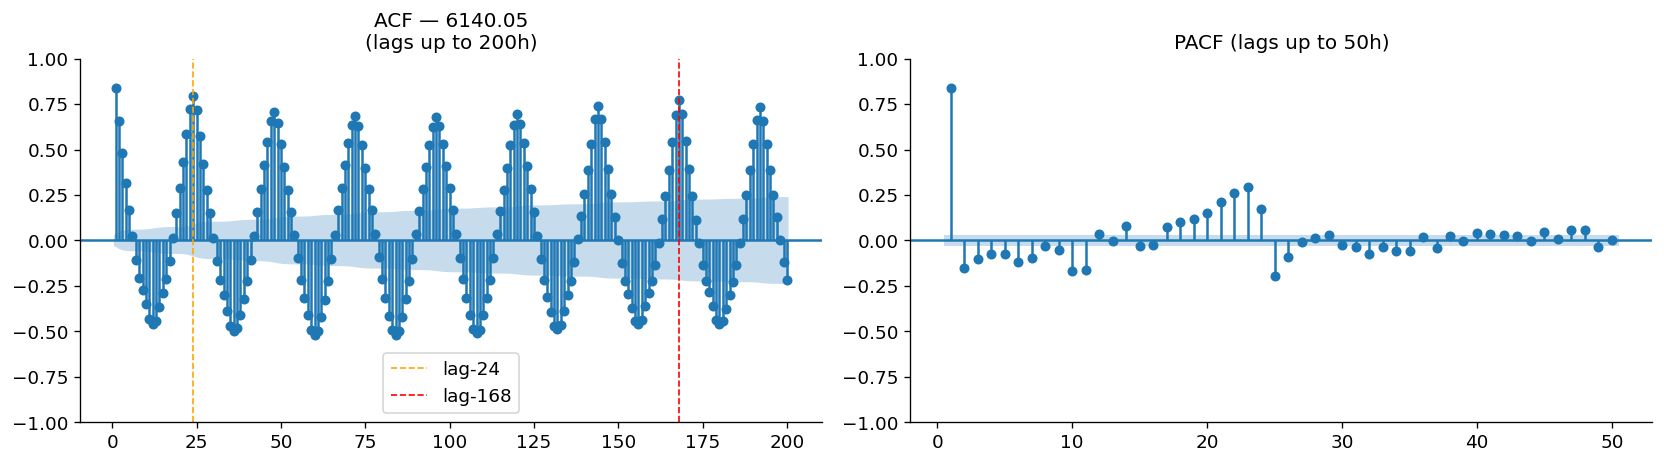

ACF/PACF plotted for station: 6140.05


In [ ]:
# Validates that lag-24 and lag-168 are meaningful predictors.

top_station = (
    demand_full.groupby("station_id")["departures"].sum().idxmax()
)
ts_sample = (
    df[df["station_id"] == top_station]
    .set_index("timestamp")["departures"]
    .sort_index()
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_sample, lags=200, ax=axes[0], alpha=0.05, zero=False)
axes[0].set_title(f"ACF — {top_station}\n(lags up to 200h)", fontsize=12)
axes[0].axvline(24,  color="orange", linestyle="--", linewidth=1, label="lag-24")
axes[0].axvline(168, color="red",    linestyle="--", linewidth=1, label="lag-168")
axes[0].legend()
plot_pacf(ts_sample, lags=50, ax=axes[1], alpha=0.05, zero=False)
axes[1].set_title("PACF (lags up to 50h)", fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "acf_pacf_top_station.png", bbox_inches="tight")
plt.show()
print(f"ACF/PACF plotted for station: {top_station}")

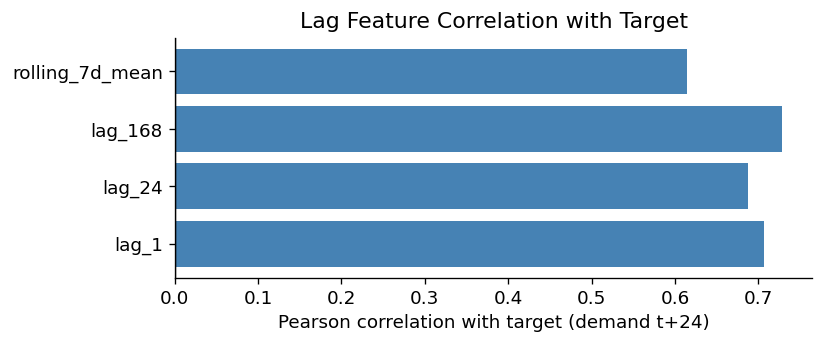

  lag_1               : r = 0.7071
  lag_24              : r = 0.6879
  lag_168             : r = 0.7285
  rolling_7d_mean     : r = 0.6143


In [ ]:
# Lag Correlations with Target
lag_cols  = ["lag_1", "lag_24", "lag_168", "rolling_7d_mean"]
lag_corrs = {col: df[col].corr(df["target_t24"]) for col in lag_cols if col in df.columns}

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(list(lag_corrs.keys()), list(lag_corrs.values()), color="steelblue")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with target (demand t+24)")
ax.set_title("Lag Feature Correlation with Target")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "lag_correlations.png", bbox_inches="tight")
plt.show()

for col, r in lag_corrs.items():
    print(f"  {col:20s}: r = {r:.4f}")

# 4.5 Spatial / Graph Features

In [ ]:
# Validate adjacency matrix alignment
assert adj_knn.shape[0]  == n_stations, f"adj_knn rows ({adj_knn.shape[0]}) ≠ n_stations ({n_stations})"
assert adj_flow.shape[0] == n_stations, f"adj_flow rows ({adj_flow.shape[0]}) ≠ n_stations ({n_stations})"
print(f"✓ Adjacency matrices aligned with {n_stations} stations.")


✓ Adjacency matrices aligned with 1911 stations.


In [ ]:
# Demand pivot matrix (timestamps × stations)
demand_pivot = (
    demand_full
    .pivot(index="timestamp", columns="station_id", values="departures")
    .sort_index()
    .fillna(0)
)
demand_pivot = demand_pivot[all_stations]   # enforce station order
print("Demand matrix (timestamps × stations):", demand_pivot.shape)

Demand matrix (timestamps × stations): (4367, 1911)


In [ ]:
# Compute Neighbor Aggregates

demand_lag1 = demand_pivot.shift(1).fillna(0).to_numpy()  # (T, N)


def row_normalise(A: np.ndarray) -> np.ndarray:
    row_sums = A.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return A / row_sums


adj_knn_norm  = row_normalise(adj_knn.copy())
adj_flow_norm = row_normalise(adj_flow.copy())

# Mean neighbour demand — (T, N) @ (N, N)^T → (T, N)
neigh_mean_knn  = demand_lag1 @ adj_knn_norm.T
neigh_mean_flow = demand_lag1 @ adj_flow_norm.T

# Max neighbour demand (KNN)
adj_knn_bin  = (adj_knn > 0).astype(float)
neigh_max_knn = np.zeros_like(demand_lag1)
for t in range(demand_lag1.shape[0]):
    masked = demand_lag1[t] * adj_knn_bin   # broadcast: (N,) * (N, N)
    neigh_max_knn[t] = masked.max(axis=1)

print("Neighbour aggregates computed.")
print(f"  neigh_mean_knn  : {neigh_mean_knn.shape}")
print(f"  neigh_mean_flow : {neigh_mean_flow.shape}")
print(f"  neigh_max_knn   : {neigh_max_knn.shape}")

Neighbour aggregates computed.
  neigh_mean_knn  : (4367, 1911)
  neigh_mean_flow : (4367, 1911)
  neigh_max_knn   : (4367, 1911)


In [ ]:
# Melt neighbour aggregates back to long format and merge
timestamps = demand_pivot.index


def matrix_to_long(matrix: np.ndarray, col_name: str) -> pd.DataFrame:
    return (
        pd.DataFrame(matrix, index=timestamps, columns=all_stations)
        .reset_index()
        .melt(id_vars="timestamp", var_name="station_id", value_name=col_name)
    )


neigh_df = (
    matrix_to_long(neigh_mean_knn,  "neigh_mean_knn")
    .merge(matrix_to_long(neigh_mean_flow, "neigh_mean_flow"), on=["timestamp", "station_id"])
    .merge(matrix_to_long(neigh_max_knn,   "neigh_max_knn"),  on=["timestamp", "station_id"])
)

df = df.merge(neigh_df, on=["timestamp", "station_id"], how="left")
print(f"Neighbour features merged. Shape: {df.shape}")
display(df.head())

Neighbour features merged. Shape: (8345337, 20)


,station_id,timestamp,departures,station_idx,hour_of_day,day_of_week,month,day_of_year,week_of_year,is_weekend,lag_1,lag_24,lag_168,rolling_7d_mean,rolling_7d_std,rolling_30d_mean,target_t24,neigh_mean_knn,neigh_mean_flow,neigh_max_knn
0,190 Morgan,2024-01-01 00:00:00,0,0,0,0,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,0.000000,0.0
1,190 Morgan,2024-01-01 01:00:00,0,0,1,0,1,1,1,0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.166667,1.666667,1.0
2,190 Morgan,2024-01-01 02:00:00,0,0,2,0,1,1,1,0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.500000,1.666667,2.0
3,190 Morgan,2024-01-01 03:00:00,0,0,3,0,1,1,1,0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,1.166667,4.833333,5.0
4,190 Morgan,2024-01-01 04:00:00,0,0,4,0,1,1,1,0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.333333,1.500000,1.0


# 4.6 Station Metadata Features

In [ ]:

meta_cols_available = stations.columns.tolist()
print("Station metadata columns:", meta_cols_available)

wanted = {
    "cluster_label",
    "lat", "lon",
    "net_flow_pct",
    "total_departures",
    "weekday_weekend_ratio",
}

col_map = {}
for want in wanted:
    for col in meta_cols_available:
        if want in col.lower() or col.lower() in want:
            col_map[want] = col
            break

print("\nMatched metadata columns:")
for k, v in col_map.items():
    print(f"  {k!r:30s} → {v!r}")

Station metadata columns: ['station_id', 'station_name', 'latitude', 'longitude', 'departures', 'arrivals', 'total_trips', 'net_flow', 'net_flow_pct', 'flow_type', 'avg_trips_per_hour', 'weekday_trips', 'weekend_trips', 'weekday_weekend_ratio', 'member_trips', 'casual_trips', 'member_casual_ratio', 'cluster', 'cluster_label', 'avg_hourly_demand']

Matched metadata columns:
  'lon'                          → 'longitude'
  'net_flow_pct'                 → 'net_flow'
  'lat'                          → 'latitude'
  'weekday_weekend_ratio'        → 'weekday_weekend_ratio'
  'cluster_label'                → 'cluster'
  'total_departures'             → 'departures'


In [ ]:
# One hot encode cluster labels if available
station_id_col = [
    c for c in stations.columns
    if "station" in c.lower() and "id" in c.lower()
][0]

stations_clean = stations[[station_id_col] + list(col_map.values())].rename(
    columns={station_id_col: "station_id", **{v: k for k, v in col_map.items()}}
)

if "cluster_label" in stations_clean.columns:
    cluster_dummies = pd.get_dummies(
        stations_clean["cluster_label"], prefix="cluster", dtype=int
    )
    stations_clean = pd.concat(
        [stations_clean.drop("cluster_label", axis=1), cluster_dummies], axis=1
    )
    print("Cluster one-hot columns:", cluster_dummies.columns.tolist())

print("Stations clean shape:", stations_clean.shape)
display(stations_clean.head())
display(cluster_dummies.head())

Cluster one-hot columns: ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3']
Stations clean shape: (1911, 10)


,station_id,lon,net_flow_pct,lat,weekday_weekend_ratio,total_departures,cluster_0,cluster_1,cluster_2,cluster_3
0,190 Morgan,-73.932096,5.0,40.711072,1.000000,1,1,0,0,0
1,4181.1,-73.953620,125.0,40.680120,2.072664,1448,0,0,0,1
2,4181.10,-73.953620,-158.0,40.680120,2.480000,3616,0,0,0,1
3,4184.08,-73.991753,25.0,40.680057,2.503632,4232,0,0,0,1
4,4193.14,-73.999057,-23.0,40.680959,3.127943,10085,0,1,0,0


,cluster_0,cluster_1,cluster_2,cluster_3
0,1,0,0,0
1,0,0,0,1
2,0,0,0,1
3,0,0,0,1
4,0,1,0,0


In [ ]:
# Merge station metadata into main df
df = df.merge(stations_clean, on="station_id", how="left")
print(f"Main df shape after metadata merge: {df.shape}")
display(df.head())

Main df shape after metadata merge: (8345337, 29)


,station_id,timestamp,departures,station_idx,hour_of_day,day_of_week,month,day_of_year,week_of_year,is_weekend,...,neigh_max_knn,lon,net_flow_pct,lat,weekday_weekend_ratio,total_departures,cluster_0,cluster_1,cluster_2,cluster_3
0,190 Morgan,2024-01-01 00:00:00,0,0,0,0,1,1,1,0,...,0.0,-73.932096,5.0,40.711072,1.0,1,1,0,0,0
1,190 Morgan,2024-01-01 01:00:00,0,0,1,0,1,1,1,0,...,1.0,-73.932096,5.0,40.711072,1.0,1,1,0,0,0
2,190 Morgan,2024-01-01 02:00:00,0,0,2,0,1,1,1,0,...,2.0,-73.932096,5.0,40.711072,1.0,1,1,0,0,0
3,190 Morgan,2024-01-01 03:00:00,0,0,3,0,1,1,1,0,...,5.0,-73.932096,5.0,40.711072,1.0,1,1,0,0,0
4,190 Morgan,2024-01-01 04:00:00,0,0,4,0,1,1,1,0,...,1.0,-73.932096,5.0,40.711072,1.0,1,1,0,0,0


# 4.7 Train Val Test Split

In [ ]:
# Features at time t only use information from ≤ t.

df_valid = df.dropna(subset=["lag_168", "target_t24"]).copy()
print(f"Rows after removing nulls: {len(df_valid):,}  (dropped {len(df) - len(df_valid):,})")

TRAIN_END = pd.Timestamp("2024-04-30 23:00:00")
VAL_END   = pd.Timestamp("2024-05-31 23:00:00")

train_mask = df_valid["timestamp"] <= TRAIN_END
val_mask   = (df_valid["timestamp"] > TRAIN_END) & (df_valid["timestamp"] <= VAL_END)
test_mask  = df_valid["timestamp"] > VAL_END

df_train = df_valid[train_mask].reset_index(drop=True)
df_val   = df_valid[val_mask].reset_index(drop=True)
df_test  = df_valid[test_mask].reset_index(drop=True)

for name, part in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    dates = f"{part['timestamp'].min().date()} → {part['timestamp'].max().date()}"
    print(f"  {name:5s}: {len(part):>10,} rows  |  {dates}")

Rows after removing nulls: 7,978,425  (dropped 366,912)
  Train:  5,228,496 rows  |  2024-01-08 → 2024-04-30
  Val  :  1,421,784 rows  |  2024-05-01 → 2024-05-31
  Test :  1,328,145 rows  |  2024-06-01 → 2024-06-29


# 4.8 Scaling and Normalization

In [ ]:
# Scalers are FIT ON TRAIN ONLY to prevent leakage.

# ── Define feature groups ─────────────────────────────────────────────────────

continuous_features = [
    "lag_1", "lag_24", "lag_168",
    "rolling_7d_mean", "rolling_7d_std", "rolling_30d_mean",
    "neigh_mean_knn", "neigh_mean_flow", "neigh_max_knn",
    "total_departures", "net_flow_pct", "weekday_weekend_ratio",
]
bounded_features = ["lat", "lon"]
passthrough_features = [
    "hour_of_day", "day_of_week", "month", "day_of_year", "week_of_year", "is_weekend",
]
cluster_features = [c for c in df_train.columns if c.startswith("cluster_")]

# Filter to only columns that actually exist
continuous_features  = [c for c in continuous_features  if c in df_train.columns]
bounded_features     = [c for c in bounded_features     if c in df_train.columns]
passthrough_features = [c for c in passthrough_features if c in df_train.columns]

all_feature_cols = continuous_features + bounded_features + passthrough_features + cluster_features

print(f"Continuous  ({len(continuous_features)}): {continuous_features}")
print(f"Bounded     ({len(bounded_features)}): {bounded_features}")
print(f"Passthrough ({len(passthrough_features)}): {passthrough_features}")
print(f"Cluster     ({len(cluster_features)}): {cluster_features}")
print(f"\nTotal features: {len(all_feature_cols)}")

Continuous  (12): ['lag_1', 'lag_24', 'lag_168', 'rolling_7d_mean', 'rolling_7d_std', 'rolling_30d_mean', 'neigh_mean_knn', 'neigh_mean_flow', 'neigh_max_knn', 'total_departures', 'net_flow_pct', 'weekday_weekend_ratio']
Bounded     (2): ['lat', 'lon']
Passthrough (6): ['hour_of_day', 'day_of_week', 'month', 'day_of_year', 'week_of_year', 'is_weekend']
Cluster     (4): ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3']

Total features: 24


In [ ]:
# Fit Scalers on train, treansforms all splits
scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()

for split_name, split_df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    if split_name == "train":
        split_df[continuous_features] = scaler_std.fit_transform(split_df[continuous_features])
        if bounded_features:
            split_df[bounded_features] = scaler_mm.fit_transform(split_df[bounded_features])
    else:
        split_df[continuous_features] = scaler_std.transform(split_df[continuous_features])
        if bounded_features:
            split_df[bounded_features] = scaler_mm.transform(split_df[bounded_features])

    split_df[all_feature_cols] = split_df[all_feature_cols].fillna(0)

print("Scaling complete.")
print("  StandardScaler mean  (first 3):", scaler_std.mean_[:3].round(4))
print("  StandardScaler scale (first 3):", scaler_std.scale_[:3].round(4))

Scaling complete.
  StandardScaler mean  (first 3): [1.6645 1.6489 1.5893]
  StandardScaler scale (first 3): [3.5552 3.5264 3.4069]


# 4.9 Feature Quality Analysis

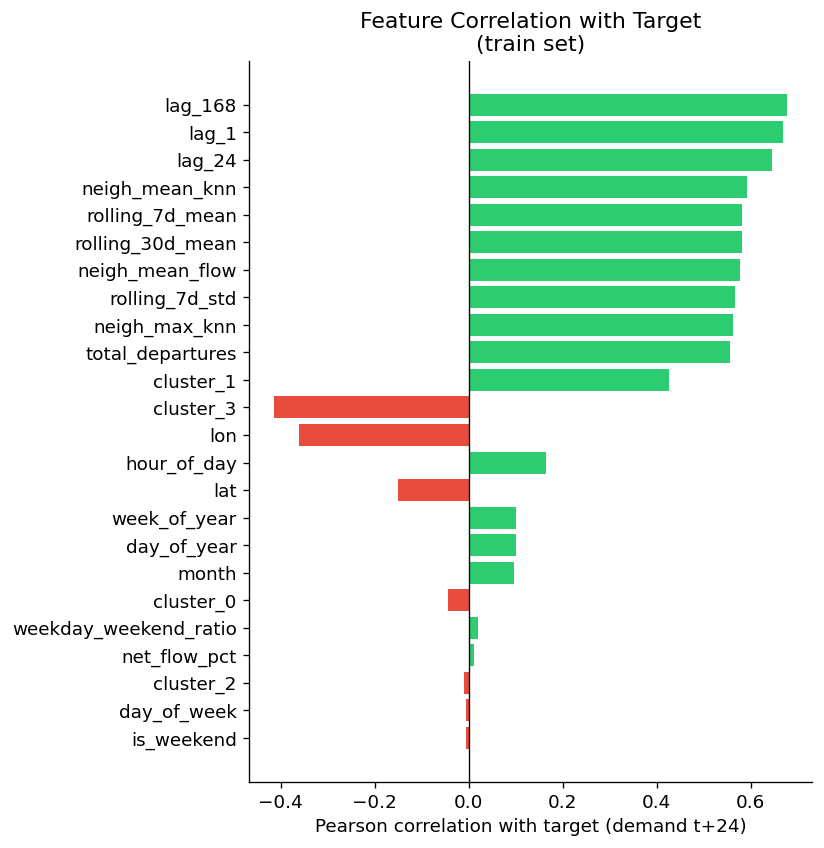

Top 10 features by absolute correlation:
lag_168             0.676979
lag_1               0.669521
lag_24              0.645910
neigh_mean_knn      0.592050
rolling_7d_mean     0.582726
rolling_30d_mean    0.581113
neigh_mean_flow     0.576576
rolling_7d_std      0.567490
neigh_max_knn       0.562563
total_departures    0.557025


In [ ]:
corr_data   = df_train[all_feature_cols + ["target_t24"]].corr()
target_corr = corr_data["target_t24"].drop("target_t24").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, max(5, len(target_corr) * 0.3)))
colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in target_corr]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with target (demand t+24)")
ax.set_title("Feature Correlation with Target\n(train set)")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "feature_target_correlation.png", bbox_inches="tight")
plt.show()

print("Top 10 features by absolute correlation:")
print(target_corr.abs().nlargest(10).to_string())

⚠️  Highly correlated feature pairs (r > 0.95):
   rolling_7d_std                 ↔ rolling_7d_mean                 r=0.971
   rolling_30d_mean               ↔ rolling_7d_mean                 r=0.977
   rolling_30d_mean               ↔ rolling_7d_std                  r=0.950
   total_departures               ↔ rolling_30d_mean                r=0.953
   day_of_year                    ↔ month                           r=0.967
   week_of_year                   ↔ month                           r=0.965
   week_of_year                   ↔ day_of_year                     r=0.998
   cluster_3                      ↔ cluster_1                       r=0.978


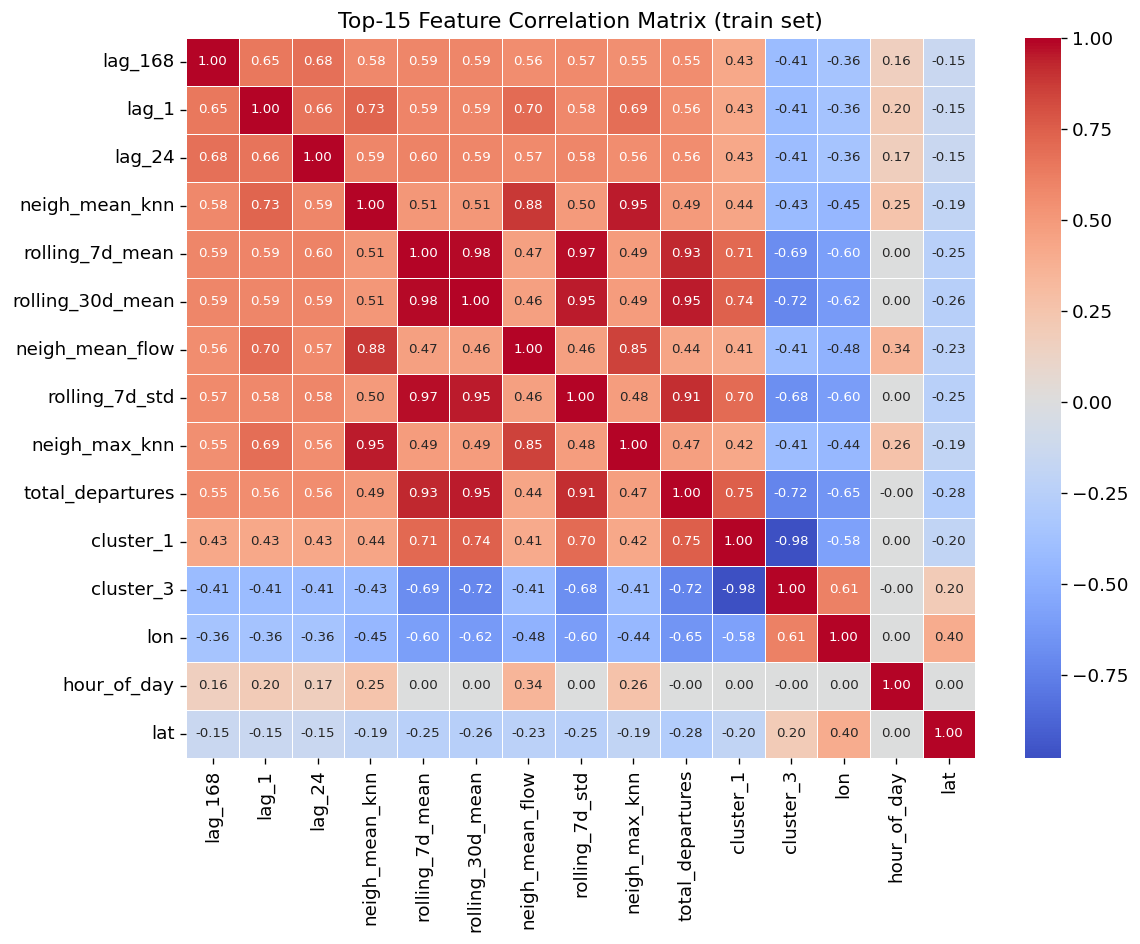

In [ ]:
# Inter-feature redundancy check (r > 0.95)
feat_corr  = df_train[all_feature_cols].corr().abs()
upper_tri  = feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper_tri.loc[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if upper_tri.loc[row, col] > 0.95
]

if high_corr_pairs:
    print("⚠️  Highly correlated feature pairs (r > 0.95):")
    for a, b, r in high_corr_pairs:
        print(f"   {a:30s} ↔ {b:30s}  r={r:.3f}")
else:
    print("✓ No feature pairs with r > 0.95 found.")

# Heatmap (top 15 features)
top_feats = target_corr.abs().nlargest(15).index.tolist()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df_train[top_feats].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    ax=ax, linewidths=0.5, annot_kws={"size": 8},
)
ax.set_title("Top-15 Feature Correlation Matrix (train set)")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "feature_correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [ ]:
# Drop redundant features
drop_features = ["rolling_30d_mean", "rolling_7d_std", "day_of_year", "week_of_year", "neigh_max_knn", "total_departures", "cluster_3"]  # Example redundant features based on correlation 

for split_df in [df_train, df_val, df_test]:
    split_df.drop(columns=drop_features, inplace=True)

continuous_features  = [c for c in continuous_features  if c not in drop_features]
passthrough_features = [c for c in passthrough_features if c not in drop_features]
all_feature_cols     = [c for c in all_feature_cols     if c not in drop_features]

print(f"Dropped: {drop_features}")
print(f"Remaining features: {len(all_feature_cols)}")

Dropped: ['rolling_30d_mean', 'rolling_7d_std', 'day_of_year', 'week_of_year', 'neigh_max_knn', 'total_departures', 'cluster_3']
Remaining features: 17


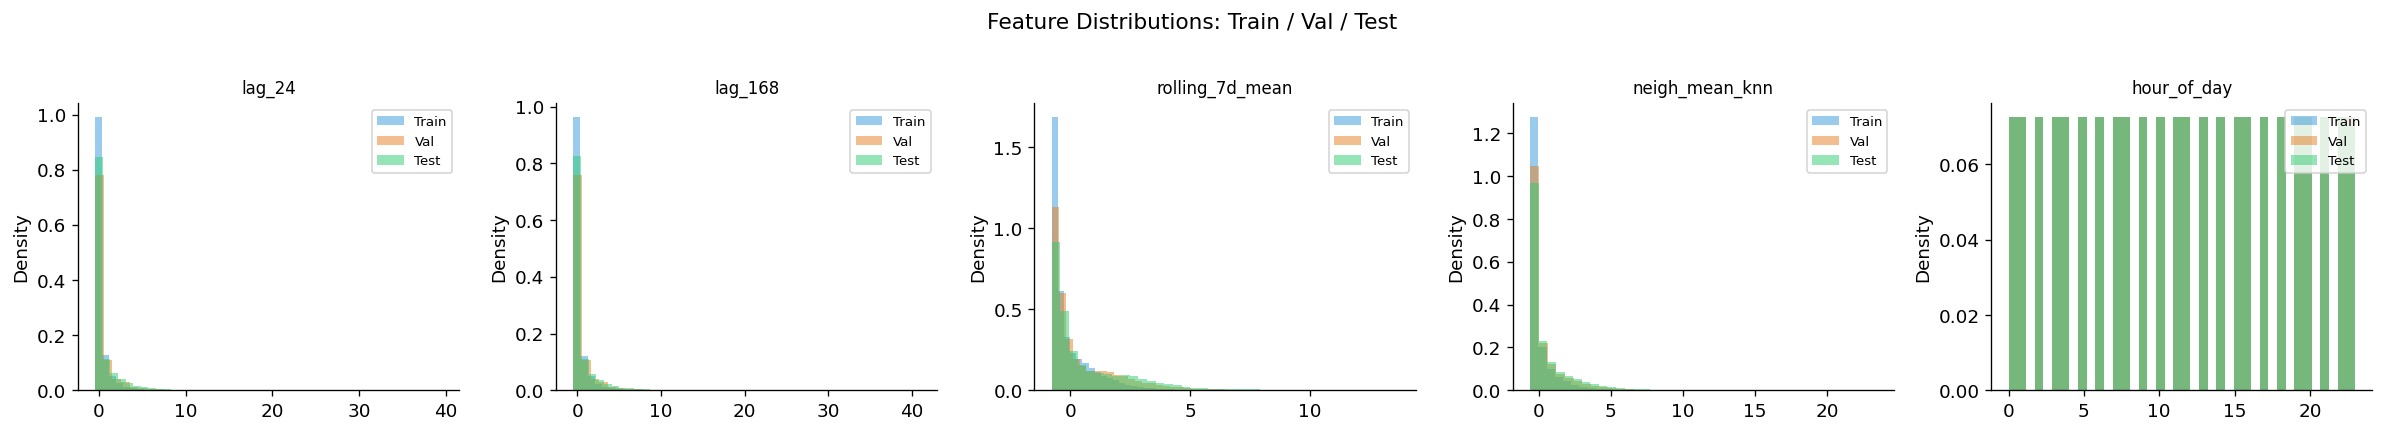

In [ ]:
# Feature distributions: train vs val vs test 

check_feats = [f for f in ["lag_24", "lag_168", "rolling_7d_mean", "neigh_mean_knn", "hour_of_day"]
               if f in all_feature_cols]

fig, axes = plt.subplots(1, len(check_feats), figsize=(4 * len(check_feats), 3.5))
if len(check_feats) == 1:
    axes = [axes]

for ax, feat in zip(axes, check_feats):
    for split_df, label, color in [
        (df_train, "Train", "#3498db"),
        (df_val,   "Val",   "#e67e22"),
        (df_test,  "Test",  "#2ecc71"),
    ]:
        ax.hist(split_df[feat].dropna(), bins=40, alpha=0.5,
                label=label, color=color, density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel("Density")

fig.suptitle("Feature Distributions: Train / Val / Test", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "feature_distributions.png", bbox_inches="tight")
plt.show()


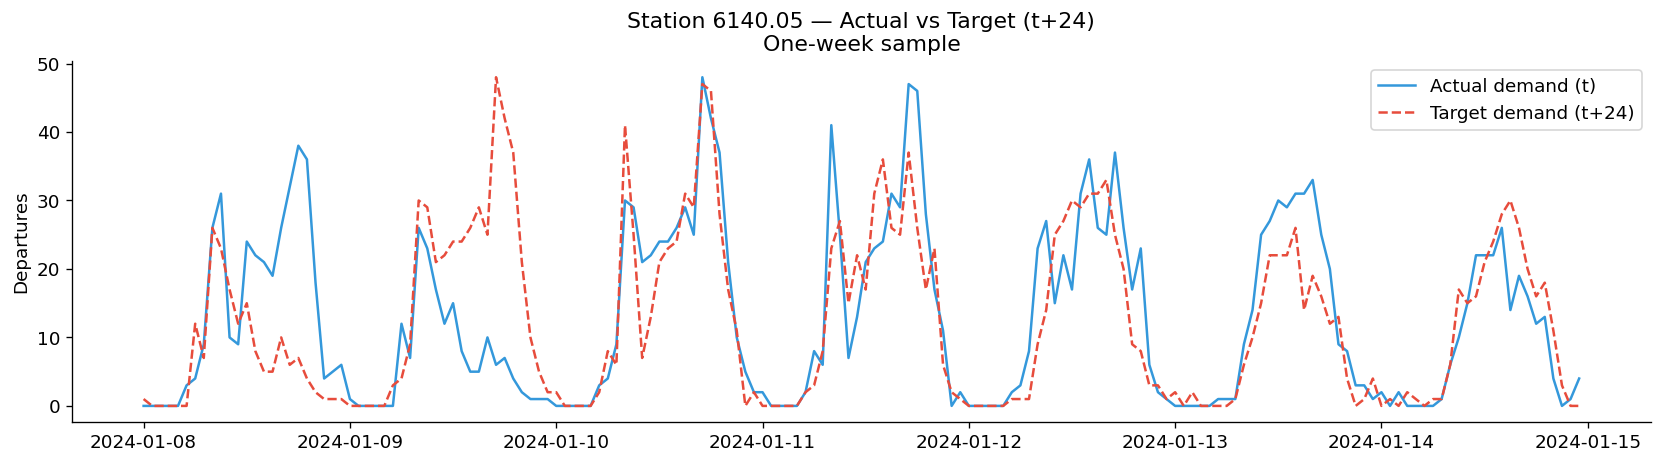

In [ ]:
# Sample t vs t+24 timeline
sample = (
    df_train[df_train["station_id"] == top_station]
    .sort_values("timestamp")
    .head(168)   # one week
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample["timestamp"], sample["departures"],  label="Actual demand (t)",    color="#3498db")
ax.plot(sample["timestamp"], sample["target_t24"],  label="Target demand (t+24)", color="#e74c3c", linestyle="--")
ax.set_title(f"Station {top_station} — Actual vs Target (t+24)\nOne-week sample")
ax.set_ylabel("Departures")
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "sample_t_vs_t24.png", bbox_inches="tight")
plt.show()

# 4.10 Save Feature Matrices and Metadata

In [ ]:
ID_COLS = ["station_id", "station_idx", "timestamp"]

X_train = df_train[ID_COLS + all_feature_cols].copy()
X_val   = df_val  [ID_COLS + all_feature_cols].copy()
X_test  = df_test [ID_COLS + all_feature_cols].copy()

y_train = df_train[ID_COLS + ["target_t24"]].copy()
y_val   = df_val  [ID_COLS + ["target_t24"]].copy()
y_test  = df_test [ID_COLS + ["target_t24"]].copy()

for name, X, y in [("Train", X_train, y_train), ("Val", X_val, y_val), ("Test", X_test, y_test)]:
    print(f"  {name:5s}  X: {X.shape}   y: {y.shape}")

  Train  X: (5228496, 20)   y: (5228496, 4)
  Val    X: (1421784, 20)   y: (1421784, 4)
  Test   X: (1328145, 20)   y: (1328145, 4)


In [ ]:
X_train.to_parquet(PROCESSED_DIR / "features_train.parquet", index=False)
X_val.to_parquet(  PROCESSED_DIR / "features_val.parquet",   index=False)
X_test.to_parquet( PROCESSED_DIR / "features_test.parquet",  index=False)

y_train.to_parquet(PROCESSED_DIR / "targets_train.parquet",  index=False)
y_val.to_parquet(  PROCESSED_DIR / "targets_val.parquet",    index=False)
y_test.to_parquet( PROCESSED_DIR / "targets_test.parquet",   index=False)

In [ ]:
# Save feature metadata for future reference and model training
feature_metadata = {
    "target": {
        "name": "target_t24",
        "description": "Hourly departures at station at time t+24 (next-day same hour)",
        "horizon_hours": 24,
    },
    "features": {
        "all":         all_feature_cols,
        "continuous":  continuous_features,
        "bounded":     bounded_features,
        "passthrough": passthrough_features,
        "cluster":     cluster_features,
        "total_count": len(all_feature_cols),
    },
    "scaling": {
        "standard_scaler": {
            "features": continuous_features,
            "mean":     scaler_std.mean_.tolist(),
            "scale":    scaler_std.scale_.tolist(),
        },
        "minmax_scaler": {
            "features": bounded_features,
            "min": scaler_mm.data_min_.tolist() if bounded_features else [],
            "max": scaler_mm.data_max_.tolist() if bounded_features else [],
        },
    },
    "splits": {
        "train": {"start": "2024-01-01", "end": "2024-04-30", "rows": len(X_train)},
        "val":   {"start": "2024-05-01", "end": "2024-05-31", "rows": len(X_val)},
        "test":  {"start": "2024-06-01", "end": "2024-06-30", "rows": len(X_test)},
    },
    "stations": {
        "count":      n_stations,
        "id_to_idx":  station_id_to_idx,
    },
    "lags_used":    [1, 24, 168],
    "warm_up_hours": 168,
    "created":       pd.Timestamp.now().isoformat(),
}

with open(PROCESSED_DIR / "feature_metadata.json", "w") as f:
    json.dump(feature_metadata, f, indent=2)

In [ ]:
# Save graph data for future reference and model training
graph_data = {
    "adj_knn":           adj_knn,
    "adj_knn_norm":      adj_knn_norm,
    "adj_flow":          adj_flow,
    "adj_flow_norm":     adj_flow_norm,
    "station_id_to_idx": station_id_to_idx,
    "idx_to_station_id": idx_to_station_id,
    "n_stations":        n_stations,
    "station_ids":       all_stations,
}

with open(PROCESSED_DIR / "graph_data.pkl", "wb") as f:
    pickle.dump(graph_data, f)

# 4.11 Data Snapshot

In [ ]:
import sys

sys.path.insert(0, str(Path("..") / "src" / "models"))
from utils import SNAPSHOT_ARTIFACTS, _sha256_file, compute_data_snapshot_id

data_snapshot_id = compute_data_snapshot_id(PROCESSED_DIR)

snapshot = {
    "data_snapshot_id": data_snapshot_id,
    "file_hashes": {
        name: _sha256_file(PROCESSED_DIR / name) for name in SNAPSHOT_ARTIFACTS
    },
    "row_counts": {
        "train": len(X_train),
        "val":   len(X_val),
        "test":  len(X_test),
    },
    "time_bounds": {
        "train": {"start": str(df_train["timestamp"].min()), "end": str(df_train["timestamp"].max())},
        "val":   {"start": str(df_val["timestamp"].min()),   "end": str(df_val["timestamp"].max())},
        "test":  {"start": str(df_test["timestamp"].min()),  "end": str(df_test["timestamp"].max())},
    },
    "created": pd.Timestamp.now().isoformat(),
}

with open(PROCESSED_DIR / "SNAPSHOT.json", "w") as f:
    json.dump(snapshot, f, indent=2)

print("data_snapshot_id:", data_snapshot_id)
print("Wrote", PROCESSED_DIR / "SNAPSHOT.json")